Génération du Graphique de Densité (Niveau 1)...


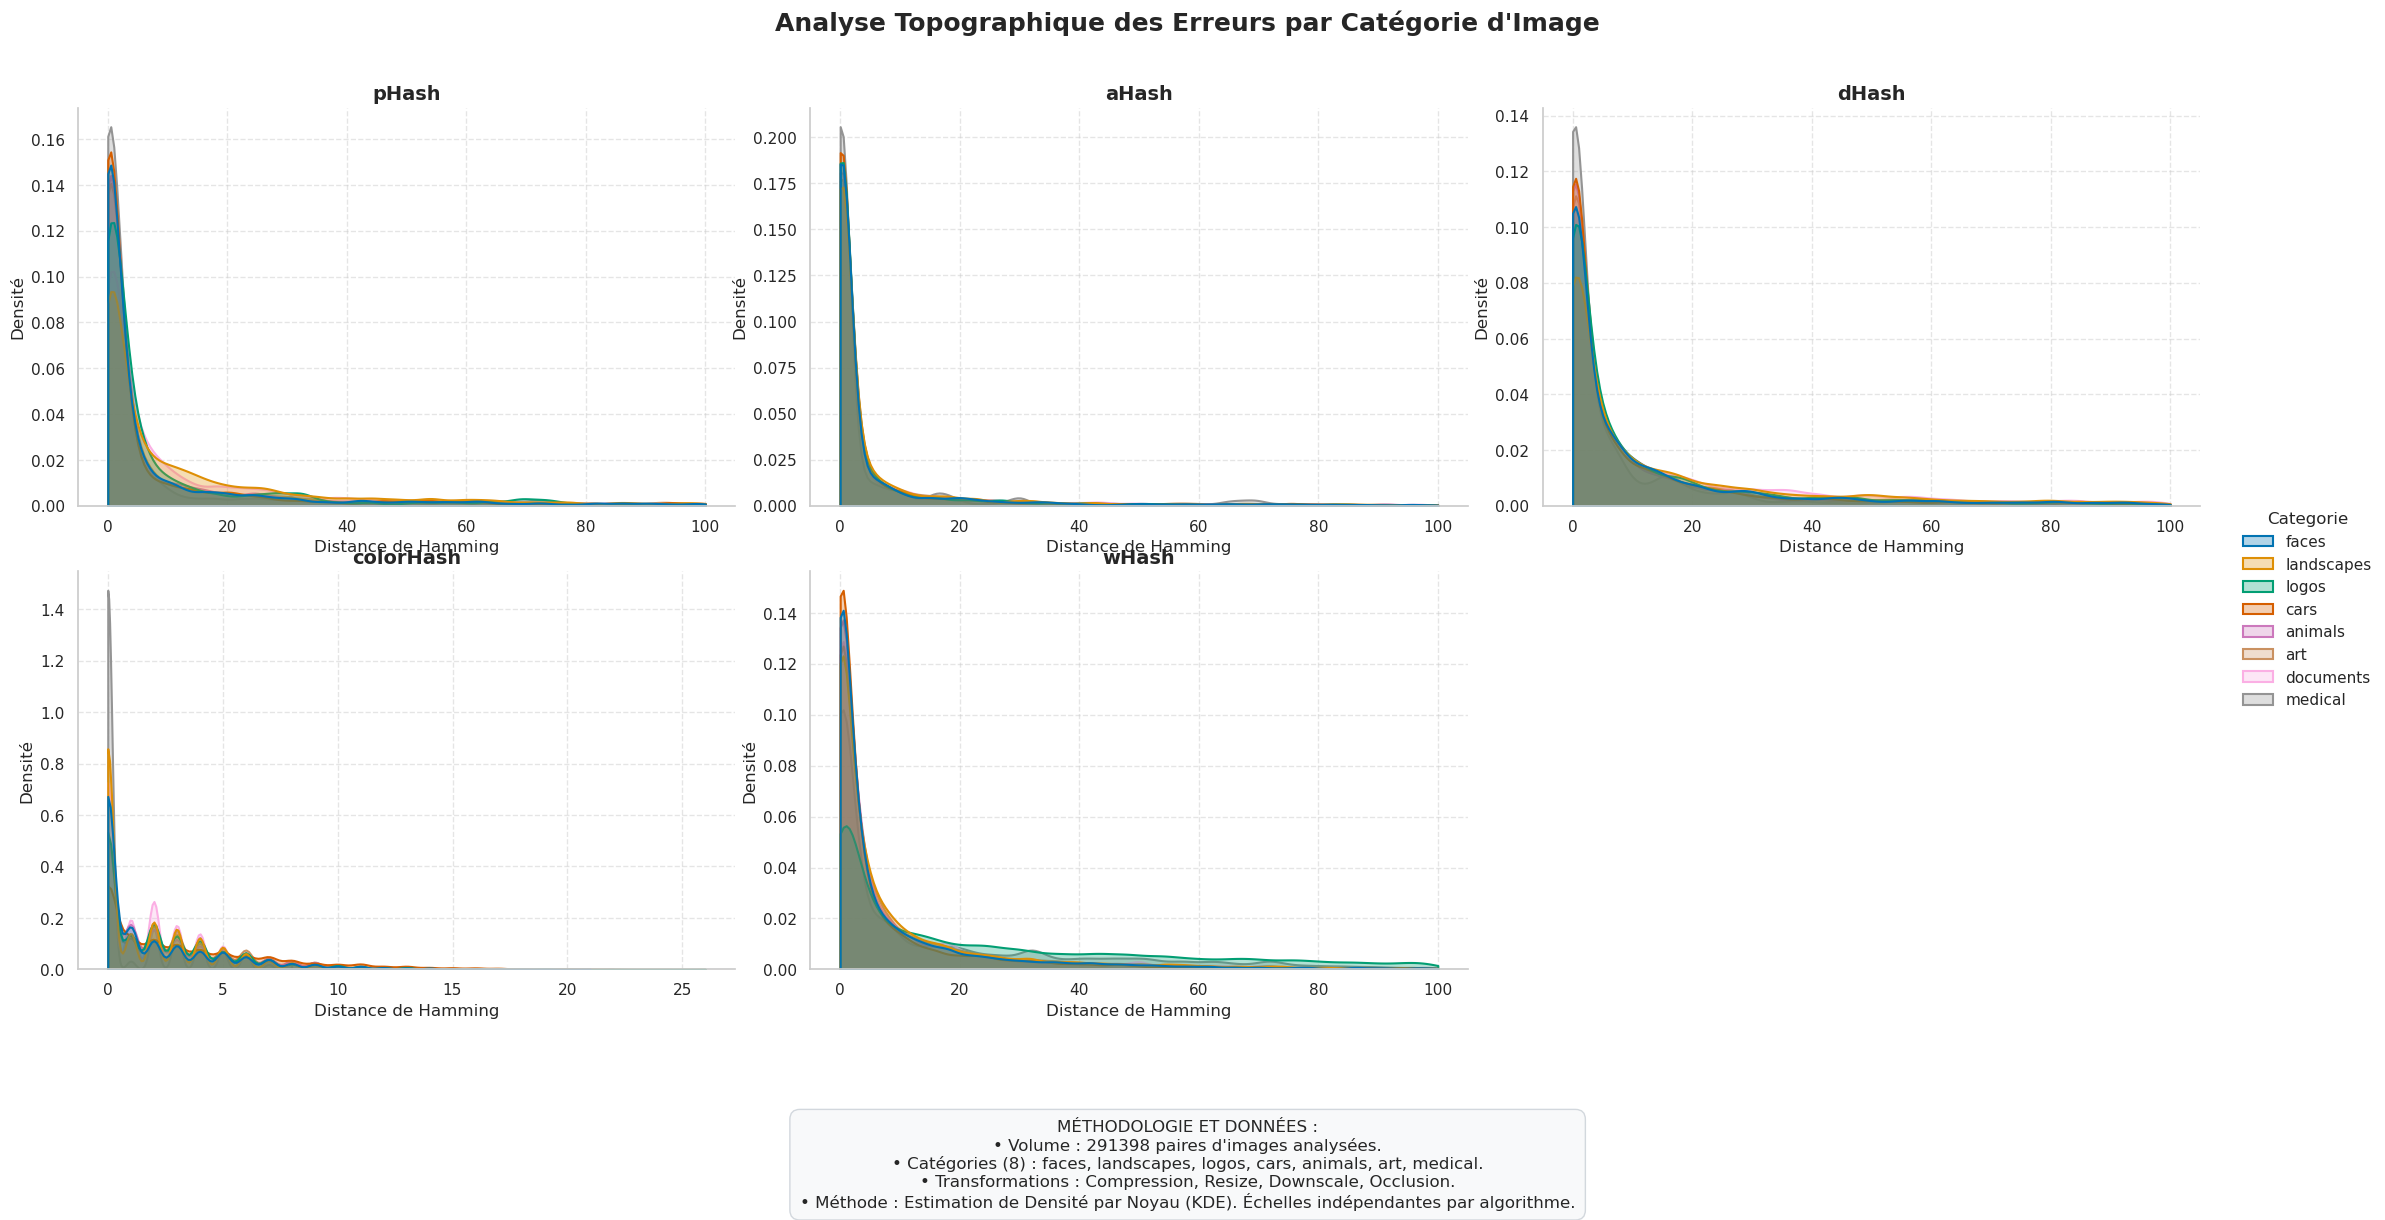

In [5]:
# ══════════════════════════════════════════════════════════════════
#  Le Diagnostic (KDE par Catégorie)
# ══════════════════════════════════════════════════════════════════
print("Génération du Graphique de Densité (Niveau 1)...")

# 1. Nettoyage des erreurs de log
df_propre = df_attaques[df_attaques['Distance_Hamming'] <= 100].copy()

# 2. Extraction des infos pour le Caption
nb_comparaisons = len(df_propre)
nb_categories = df_propre['Categorie'].nunique()
attaques_uniques = df_propre['Type_Attaque'].unique()
liste_attaques = ", ".join(attaques_uniques)

# 3. Création du graphique (Fermetures agrandies et lissage corrigé)
g = sns.displot(
    data=df_propre,
    x="Distance_Hamming",
    hue="Categorie",       
    col="Algorithme",      
    col_wrap=3,            
    kind="kde",            
    fill=True,             
    alpha=0.3,             
    common_norm=False,     
    bw_adjust=0.5,         # Rend les pics plus nets
    cut=0,                 # Empêche la courbe de déborder dans les négatifs
    facet_kws={'sharex': False, 'sharey': False}, 
    height=5,              # Fenêtres plus grandes en hauteur
    aspect=1.5,            # Fenêtres plus larges
    linewidth=1.5
)

# --- Esthétique ---
g.fig.suptitle("Analyse Topographique des Erreurs par Catégorie d'Image", 
               fontsize=18, fontweight='bold', y=1.06)

for ax in g.axes.flat:
    titre_actuel = ax.get_title()
    nouveau_titre = titre_actuel.replace("Algorithme = ", "")
    ax.set_title(f"{nouveau_titre}", fontweight='bold', fontsize=14)
    ax.set_xlabel("Distance de Hamming", fontsize=12)
    ax.set_ylabel("Densité", fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.5)

# --- Ajout du Caption ---
caption_texte = (
    f"MÉTHODOLOGIE ET DONNÉES :\n"
    f"• Volume : {nb_comparaisons} paires d'images analysées.\n"
    f"• Catégories ({nb_categories}) : faces, landscapes, logos, cars, animals, art, medical.\n"
    f"• Transformations : {liste_attaques}.\n"
    f"• Méthode : Estimation de Densité par Noyau (KDE). Échelles indépendantes par algorithme."
)

# Placement du texte sous la figure
g.fig.text(0.5, -0.05, caption_texte, ha='center', va='top', fontsize=12, 
           bbox=dict(boxstyle="round,pad=0.6", facecolor="#f8f9fa", edgecolor="#ced4da", alpha=0.9))


plt.subplots_adjust(bottom=0.1)

# --- Sauvegarde ---
chemin_image_1 = os.path.join(dossier_analyse, "Niveau_1_KDE_Final.jpg")
plt.savefig(chemin_image_1, dpi=120, bbox_inches='tight')

plt.show()

Génération des Diagrammes en Violon 


/tmp/ipykernel_14386/2891726874.py:22: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  g = sns.catplot(


Fichier créé : resultats_CR11/Analyse/Niveau_1_Violon_Spatiaux.jpg


/tmp/ipykernel_14386/2891726874.py:22: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  g = sns.catplot(


Fichier créé : resultats_CR11/Analyse/Niveau_1_Violon_Frequenciels.jpg


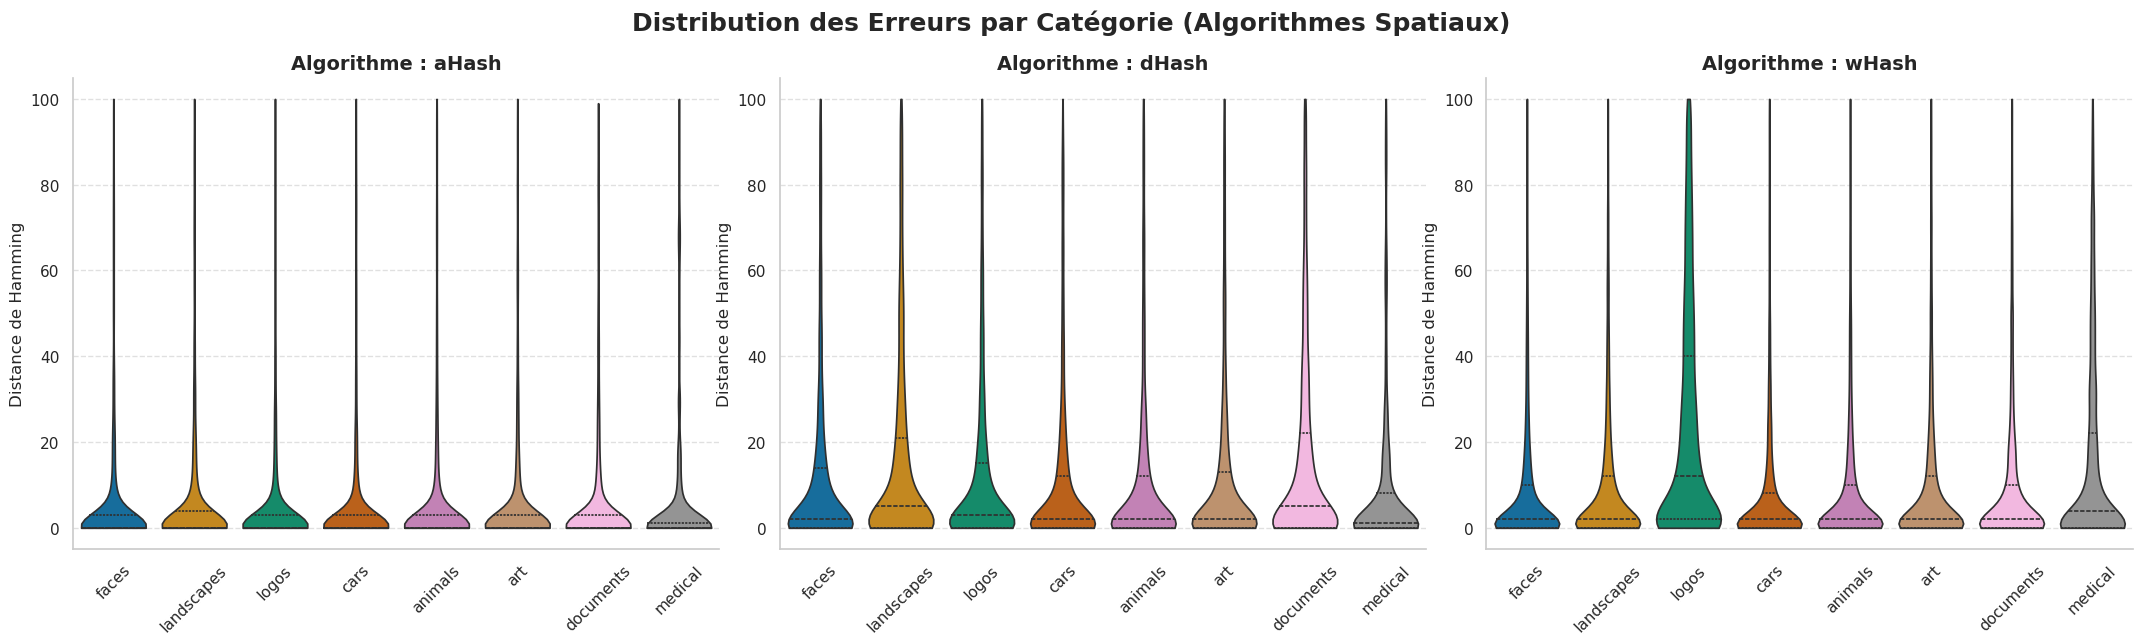

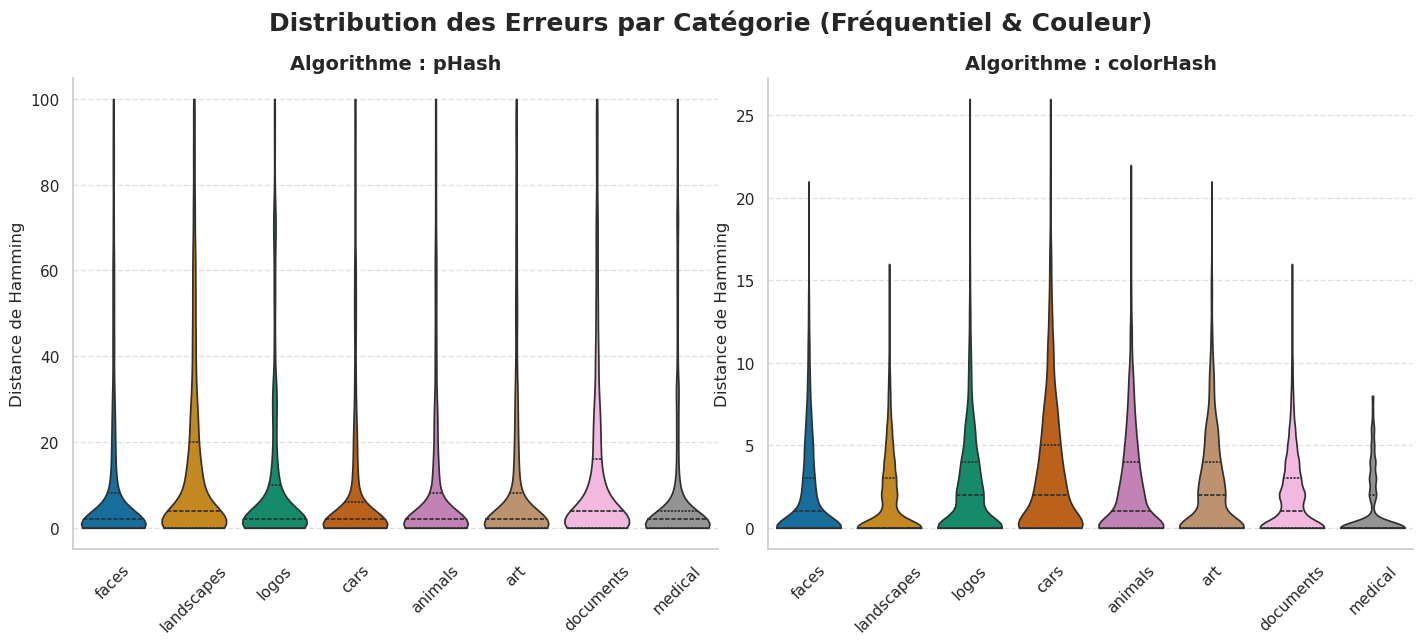

In [7]:
# ══════════════════════════════════════════════════════════════════
#  Diagrammes en Violon
# ══════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("Génération des Diagrammes en Violon ")

# 1. Nettoyage des erreurs extrêmes pour ne pas écraser l'échelle
df_propre = df_attaques[df_attaques['Distance_Hamming'] <= 100].copy()

# 2. Séparation en deux groupes pour alléger les images (2 images au lieu d'une)
groupe_1 = ['aHash', 'dHash', 'wHash'] # Algorithmes "Spatiaux"
groupe_2 = ['pHash', 'colorHash']      # Algorithmes "Fréquentiels & Couleur"

# --- FONCTION POUR GÉNÉRER ET SAUVEGARDER UNE IMAGE ---
def creer_image_violon(liste_algos, nom_fichier, titre_principal):
    df_filtre = df_propre[df_propre['Algorithme'].isin(liste_algos)]
    
    # Création du graphique (Une colonne par algorithme)
    g = sns.catplot(
        data=df_filtre,
        x="Categorie", 
        y="Distance_Hamming", 
        col="Algorithme",
        kind="violin",       # La magie opère ici : courbes verticales côte à côte
        hue="Categorie",     # Coloration
        cut=0,               # Coupe les valeurs négatives
        scale="width",       # Tous les violons ont la même largeur max
        inner="quartile",    # Dessine les lignes Q1, Médiane, Q3 à l'intérieur
        height=6,            # TRÈS grande fenêtre
        aspect=1.2,          # Largeur de la fenêtre
        sharey=False         # Échelles Y indépendantes (important pour colorHash)
    )
    
    g.fig.suptitle(titre_principal, fontsize=18, fontweight='bold', y=1.05)
    
    # Rotation des étiquettes (logos, faces, etc.) pour qu'elles soient lisibles
    for ax in g.axes.flat:
        titre_actuel = ax.get_title().replace("Algorithme = ", "")
        ax.set_title(f"Algorithme : {titre_actuel}", fontsize=14, fontweight='bold')
        ax.set_xlabel("")
        ax.set_ylabel("Distance de Hamming", fontsize=12)
        ax.tick_params(axis='x', rotation=45) # Penche le texte à 45 degrés
        ax.grid(True, axis='y', linestyle='--', alpha=0.6)

    plt.subplots_adjust(bottom=0.15)
    
    # Sauvegarde
    chemin = os.path.join(dossier_analyse, nom_fichier)
    plt.savefig(chemin, dpi=120, bbox_inches='tight')
    print(f"Fichier créé : {chemin}")

# --- EXÉCUTION POUR LES DEUX GROUPES ---
creer_image_violon(groupe_1, "Niveau_1_Violon_Spatiaux.jpg", 
                   "Distribution des Erreurs par Catégorie (Algorithmes Spatiaux)")

creer_image_violon(groupe_2, "Niveau_1_Violon_Frequenciels.jpg", 
                   "Distribution des Erreurs par Catégorie (Fréquentiel & Couleur)")

plt.show()

Génération des Violons par Type d'Attaque...


/tmp/ipykernel_14386/2277455201.py:10: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  g = sns.catplot(


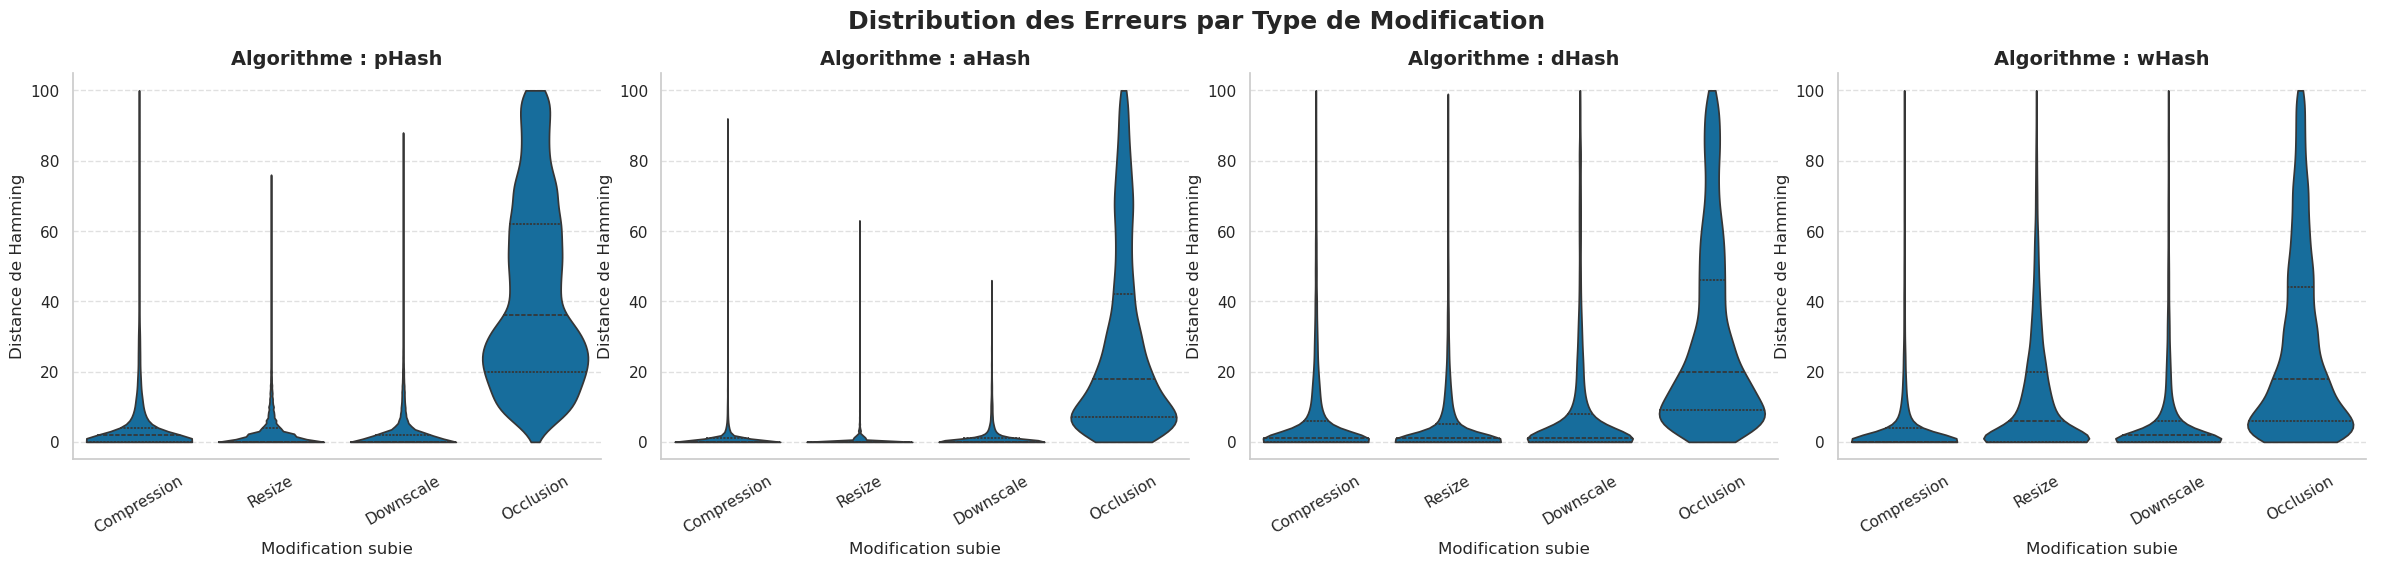

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("Génération des Violons par Type d'Attaque...")

df_propre = df_attaques[df_attaques['Distance_Hamming'] <= 100].copy()
algos_spatiaux = ['aHash', 'pHash', 'dHash', 'wHash'] # On exclut colorHash pour l'échelle

g = sns.catplot(
    data=df_propre[df_propre['Algorithme'].isin(algos_spatiaux)],
    x="Type_Attaque", 
    y="Distance_Hamming", 
    col="Algorithme",
    kind="violin",       
    cut=0,               
    scale="width",       
    inner="quartile",    
    height=5,            
    aspect=1.2,          
    sharey=False
)

g.fig.suptitle("Distribution des Erreurs par Type de Modification", fontsize=18, fontweight='bold', y=1.05)

for ax in g.axes.flat:
    titre = ax.get_title().replace("Algorithme = ", "")
    ax.set_title(f"Algorithme : {titre}", fontsize=14, fontweight='bold')
    ax.set_xlabel("Modification subie", fontsize=12)
    ax.set_ylabel("Distance de Hamming", fontsize=12)
    ax.tick_params(axis='x', rotation=30)
    ax.grid(True, axis='y', linestyle='--', alpha=0.6)

plt.subplots_adjust(bottom=0.15)
chemin = os.path.join(dossier_analyse, "Niveau_1_Attaques.jpg")
plt.savefig(chemin, dpi=120, bbox_inches='tight')
plt.show()

/tmp/ipykernel_14386/789060831.py:33: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  g = sns.catplot(
/tmp/ipykernel_14386/789060831.py:33: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  g = sns.catplot(
/tmp/ipykernel_14386/789060831.py:33: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  g = sns.catplot(
/tmp/ipykernel_14386/789060831.py:33: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  g = sns.catplot(


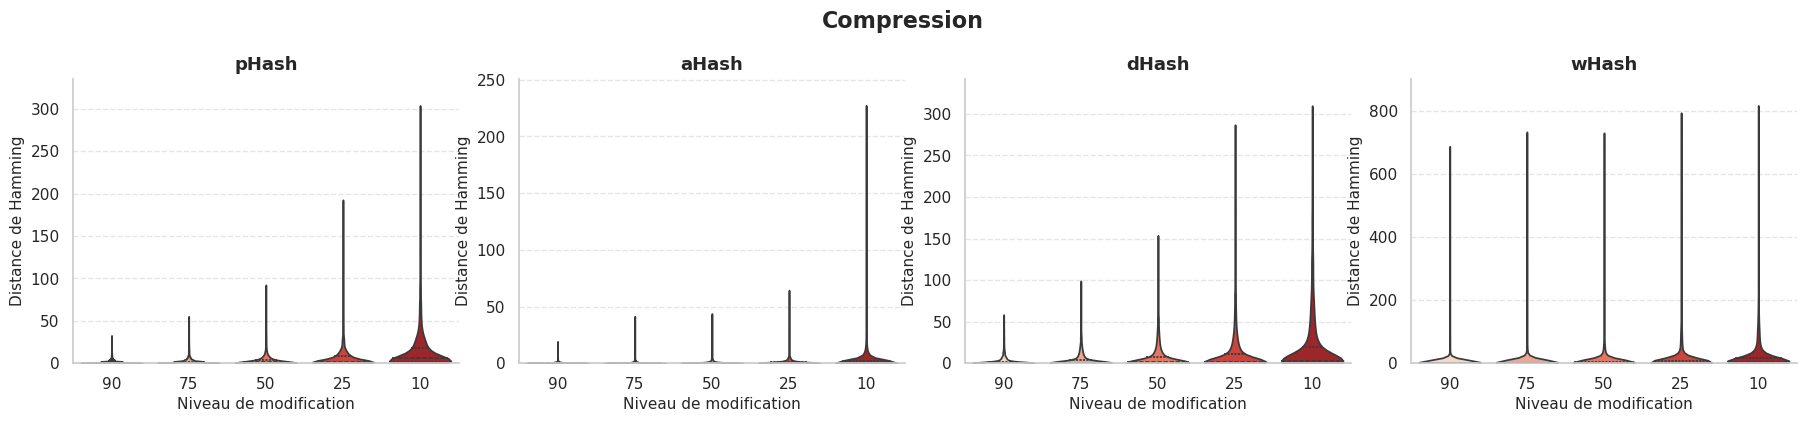

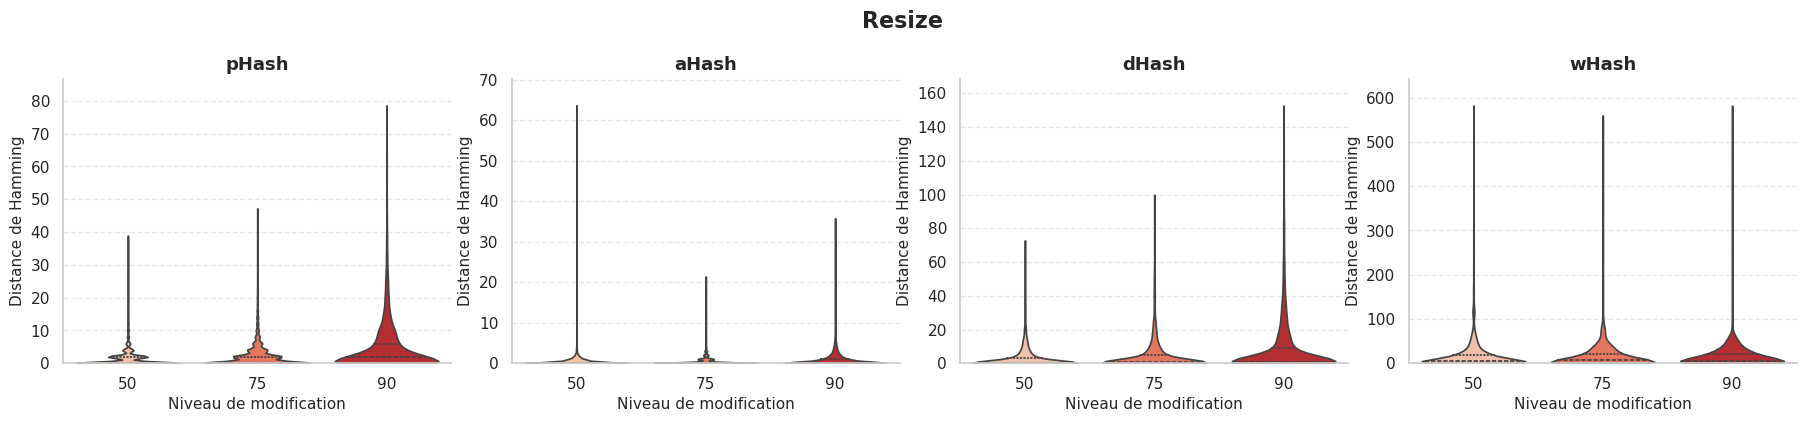

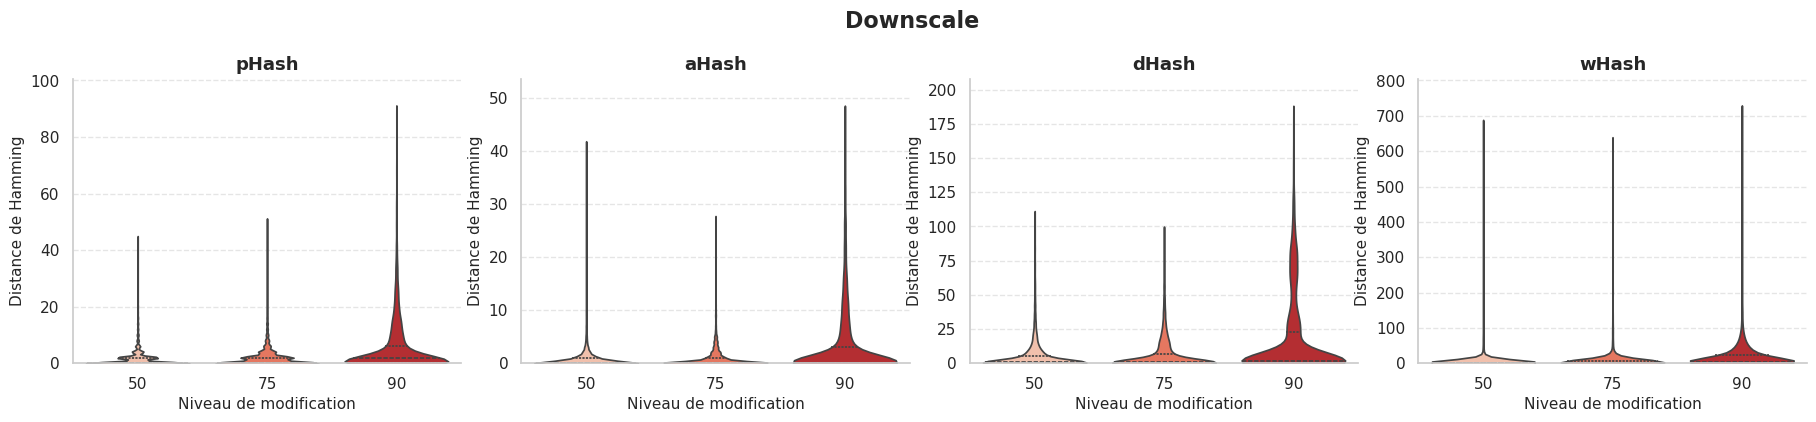

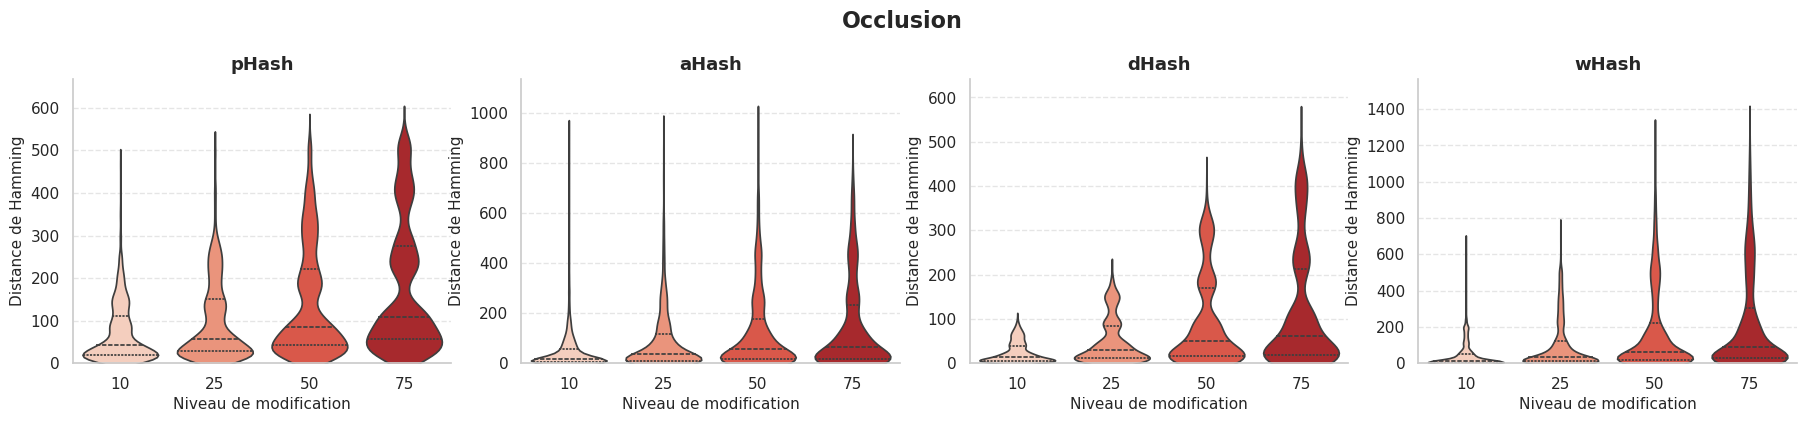

In [13]:
# ══════════════════════════════════════════════════════════════════
# Évolution des erreurs selon l'Intensité
# ══════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import seaborn as sns
import os

#print("Génération de l'évolution par Intensité...")

algos_spatiaux = ['aHash', 'pHash', 'dHash', 'wHash']
df_filtre = df_attaques[df_attaques['Algorithme'].isin(algos_spatiaux)].copy()

# On la convertit en texte pur (ex: 90.0 devient "90") pour correspondre à notre ordre
df_filtre['Niveau'] = df_filtre['Intensite'].astype(str).str.replace('.0', '', regex=False)

# Ordre d'agressivité (du plus LÉGER au plus DESTRUCTEUR)
ordres_agressivite = {
    'Compression': ['90', '75', '50', '25', '10'], 
    'Resize': ['50', '75', '90'],
    'Downscale': ['50', '75', '90'],
    'Occlusion': ['10', '25', '50', '75']
}

for attaque, ordre in ordres_agressivite.items():
    
    # On filtre sur le mot clé de l'attaque
    df_focus = df_filtre[df_filtre['Type_Attaque'].str.contains(attaque, case=False)]
    
    if df_focus.empty:
        print(f" Aucune donnée trouvée pour {attaque}.")
        continue
        
    g = sns.catplot(
        data=df_focus,
        x="Niveau", 
        y="Distance_Hamming", 
        hue="Niveau",        # Requis par les nouvelles versions de Seaborn avec palette
        col="Algorithme",
        kind="violin", 
        order=ordre,         
        hue_order=ordre,     # Force la couleur à suivre le même ordre
        palette="Reds",      
        scale="width",       
        inner="quartile",
        height=3.8,          
        aspect=1.2,
        sharey=False,
        legend=False         # On cache la légende inutile
    )

    g.fig.suptitle(f"{attaque}", fontsize=16, fontweight='bold', y=1.08)

    for ax in g.axes.flat:
        titre = ax.get_title().replace("Algorithme = ", "")
        ax.set_title(f"{titre}", fontweight='bold', fontsize=13)
        ax.set_xlabel("Niveau de modification", fontsize=11)
        ax.set_ylabel("Distance de Hamming", fontsize=11)
        ax.grid(True, axis='y', linestyle='--', alpha=0.5)
        
        # Astuce visuelle pour ne pas couper le haut du violon
        y_max = ax.get_ylim()[1]
        ax.set_ylim(bottom=0, top=y_max * 1.05)

    plt.subplots_adjust(bottom=0.15)
    
    nom_fichier = f"Niveau_1_Intensite_{attaque}.jpg"
    chemin = os.path.join(dossier_analyse, nom_fichier)
    plt.savefig(chemin, dpi=120, bbox_inches='tight')
    
plt.show()

In [14]:
# ══════════════════════════════════════════════════════════════════
# CELLULE 0 — Fiche d'Identité du Dataset (Pour l'introduction du rapport)
# ══════════════════════════════════════════════════════════════════
from IPython.display import display, Markdown

print("Génération de la Fiche d'Identité du Dataset...\n")

# 1. Calculs des métriques globales
nb_total_lignes = len(df_attaques)
categories = df_attaques['Categorie'].unique()
nb_categories = len(categories)
algorithmes = df_attaques['Algorithme'].unique()
nb_algos = len(algorithmes)

# 2. Analyse dynamique des attaques et de leurs intensités
# On crée un dictionnaire qui associe chaque attaque à ses niveaux d'intensité
recap_attaques = df_attaques.groupby('Type_Attaque')['Intensite'].unique().to_dict()

# 3. Construction du rapport textuel (Format Markdown)
rapport_md = f"""
### 📊 Fiche d'Identité du Périmètre d'Évaluation

**1. Volume Global des Données**
* **Total des observations générées :** `{nb_total_lignes:,}` comparaisons (points de données sur les graphiques).
* **Algorithmes évalués ({nb_algos}) :** {', '.join(algorithmes)}
* **Catégories d'images ({nb_categories}) :** {', '.join(categories)}

**2. Matrice des Altérations (Scénarios d'attaque)**
"""

total_scenarios = 0

for attaque, intensites in recap_attaques.items():
    # Tri et nettoyage visuel des intensités (enlève les .0)
    intensites_triees = sorted([float(x) for x in intensites])
    intensites_propres = [str(int(x)) if x.is_integer() else str(x) for x in intensites_triees]
    
    nb_niveaux = len(intensites_propres)
    total_scenarios += nb_niveaux
    rapport_md += f"* **{attaque.capitalize()}** : {nb_niveaux} niveaux d'intensité $\\rightarrow$ [{', '.join(intensites_propres)}]\n"

rapport_md += f"\n**Total des scénarios de modifications distincts :** `{total_scenarios}`"

# 4. Affichage propre dans le Notebook
display(Markdown(rapport_md))

# 5. Affichage brut (Facultatif, pratique pour copier-coller dans Typst)
print("-" * 60)
print("COPIE BRUTE POUR TON RAPPORT TYPST :")
print("-" * 60)
print(f"- Volume total : {nb_total_lignes} comparaisons.")
print(f"- Algorithmes ({nb_algos}) : {', '.join(algorithmes)}")
print(f"- Catégories ({nb_categories}) : {', '.join(categories)}")
for attaque, intensites in recap_attaques.items():
    intensites_triees = sorted([float(x) for x in intensites])
    intensites_propres = [str(int(x)) if x.is_integer() else str(x) for x in intensites_triees]
    print(f"- {attaque.capitalize()} ({len(intensites_propres)} niveaux) : {', '.join(intensites_propres)}")

Génération de la Fiche d'Identité du Dataset...




### 📊 Fiche d'Identité du Périmètre d'Évaluation

**1. Volume Global des Données**
* **Total des observations générées :** `321,600` comparaisons (points de données sur les graphiques).
* **Algorithmes évalués (5) :** pHash, aHash, dHash, colorHash, wHash
* **Catégories d'images (8) :** faces, landscapes, logos, cars, animals, art, documents, medical

**2. Matrice des Altérations (Scénarios d'attaque)**
* **Compression** : 5 niveaux d'intensité $\rightarrow$ [10, 25, 50, 75, 90]
* **Downscale** : 3 niveaux d'intensité $\rightarrow$ [50, 75, 90]
* **Occlusion** : 4 niveaux d'intensité $\rightarrow$ [10, 25, 50, 75]
* **Resize** : 3 niveaux d'intensité $\rightarrow$ [50, 75, 90]

**Total des scénarios de modifications distincts :** `15`

------------------------------------------------------------
COPIE BRUTE POUR TON RAPPORT TYPST :
------------------------------------------------------------
- Volume total : 321600 comparaisons.
- Algorithmes (5) : pHash, aHash, dHash, colorHash, wHash
- Catégories (8) : faces, landscapes, logos, cars, animals, art, documents, medical
- Compression (5 niveaux) : 10, 25, 50, 75, 90
- Downscale (3 niveaux) : 50, 75, 90
- Occlusion (4 niveaux) : 10, 25, 50, 75
- Resize (3 niveaux) : 50, 75, 90


Génération de la Heatmap des Vulnérabilités...


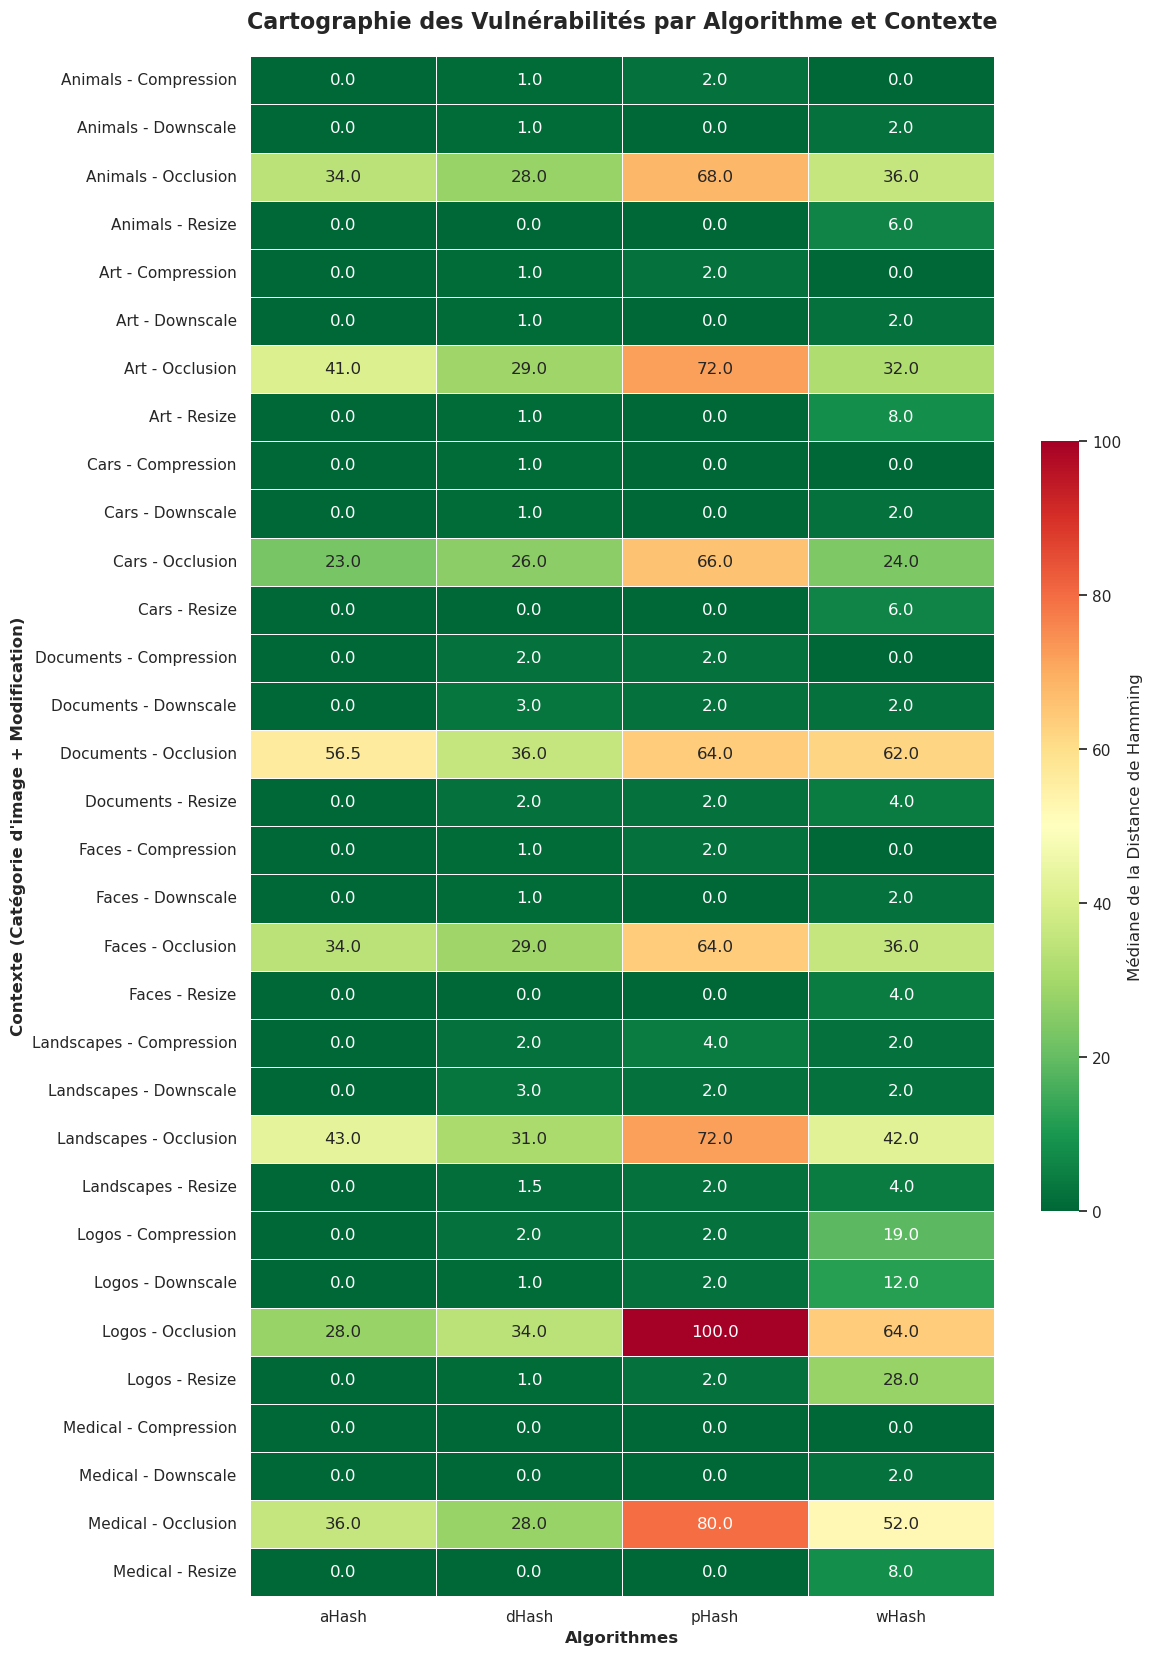

In [15]:
# ══════════════════════════════════════════════════════════════════
# CELLULE 3 — Niveau 2 : Cartographie des Vulnérabilités (Heatmap)
# ══════════════════════════════════════════════════════════════════
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

print("Génération de la Heatmap des Vulnérabilités...")

# 1. Préparation des données : On cherche la Distance Médiane
# On exclut colorHash pour l'instant car son échelle (0-1) écraserait les couleurs
# des algorithmes spatiaux (qui vont de 0 à 64).
df_heat = df_attaques[df_attaques['Algorithme'] != 'colorHash'].copy()

# On crée une nouvelle colonne "Contexte" (ex: "Logos - Compression_90") pour l'axe vertical
df_heat['Contexte'] = df_heat['Categorie'].str.capitalize() + " - " + df_heat['Type_Attaque']

# Le tableau croisé dynamique avec la "médiane" (pour ignorer les extrêmes)
pivot = df_heat.pivot_table(
    values='Distance_Hamming', 
    index='Contexte', 
    columns='Algorithme', 
    aggfunc='median'
)

# 2. Création et formatage de la Heatmap
# On prévoit une figure très haute pour que tous les textes soient lisibles
plt.figure(figsize=(12, 20)) 

# Palette divergente : Vert (0 erreur, robuste) vers Rouge (erreurs élevées, faille)
ax = sns.heatmap(
    pivot, 
    annot=True,          # Affiche les chiffres dans les cases
    fmt=".1f",           # 1 chiffre après la virgule
    cmap="RdYlGn_r",     # Inversion de la palette (Red-Yellow-Green)
    linewidths=.5,       # Sépare les cases par une petite ligne
    cbar_kws={'label': 'Médiane de la Distance de Hamming', 'shrink': 0.5}
)

# Esthétique des titres
plt.title("Cartographie des Vulnérabilités par Algorithme et Contexte", fontsize=16, fontweight='bold', pad=20)
plt.ylabel("Contexte (Catégorie d'image + Modification)", fontsize=12, fontweight='bold')
plt.xlabel("Algorithmes", fontsize=12, fontweight='bold')

# 3. Sauvegarde optimisée pour Typst
chemin_heatmap = os.path.join(dossier_analyse, "Niveau_2_Heatmap_Vuln.jpg")
plt.savefig(chemin_heatmap, dpi=120, bbox_inches='tight')



plt.show()